In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print(f"orders: {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"order_reviews: {order_reviews.shape}")
print(f"customers: {customers.shape}")
print(f"products: {products.shape}")
print(f"category_translation: {category_translation.shape}")



orders: (99441, 8)
order_items: (112650, 7)
order_reviews: (99224, 7)
customers: (99441, 5)
products: (32951, 9)
category_translation: (71, 2)


In [6]:
df = orders.merge(order_items, on='order_id', how='inner')
df = df.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')
df = df.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

print(f"Merged shape: {df.shape}")

df = df[df['order_status'] == 'delivered'].copy()
print(f"Delivered orders (line-item level): {df.shape}")

orders_delivered = df.drop_duplicates(subset='order_id').copy()
print(f"Delivered orders: {orders_delivered.shape}")

Merged shape: (113314, 16)
Delivered orders (line-item level): (110840, 16)
Delivered orders: (96478, 16)


In [7]:
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(orders_delivered['order_purchase_timestamp'])
orders_delivered['order_delivered_customer_date'] = pd.to_datetime(orders_delivered['order_delivered_customer_date'])

orders_delivered['YearMonth'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

cohort_month = orders_delivered.groupby('customer_unique_id')['YearMonth'].transform('min')
orders_delivered['CohortMonth'] = cohort_month

orders_delivered['CohortIndex'] = (
    (orders_delivered['YearMonth'].dt.year - orders_delivered['CohortMonth'].dt.year) * 12 +
    (orders_delivered['YearMonth'].dt.month - orders_delivered['CohortMonth'].dt.month)
)

orders_delivered[['customer_unique_id', 'order_purchase_timestamp', 'YearMonth', 'CohortMonth', 'CohortIndex']].head()

,customer_unique_id,order_purchase_timestamp,YearMonth,CohortMonth,CohortIndex
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02,0


In [8]:
cohort_data = orders_delivered.groupby(['CohortMonth', 'CohortIndex'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='customer_unique_id')
cohort_pivot.index = cohort_pivot.index.astype(str)

cohort_sizes = cohort_pivot[0]
print("Cohort sizes (month 0):")
print(cohort_sizes)
print(f"\nSmallest cohort: {cohort_sizes.idxmin()} ({cohort_sizes.min()} customers)")
print(f"Largest cohort: {cohort_sizes.idxmax()} ({cohort_sizes.max()} customers)")

Cohort sizes (month 0):
CohortMonth
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Name: 0, dtype: float64

Smallest cohort: 2016-09 (1.0 customers)
Largest cohort: 2017-11 (7060.0 customers)


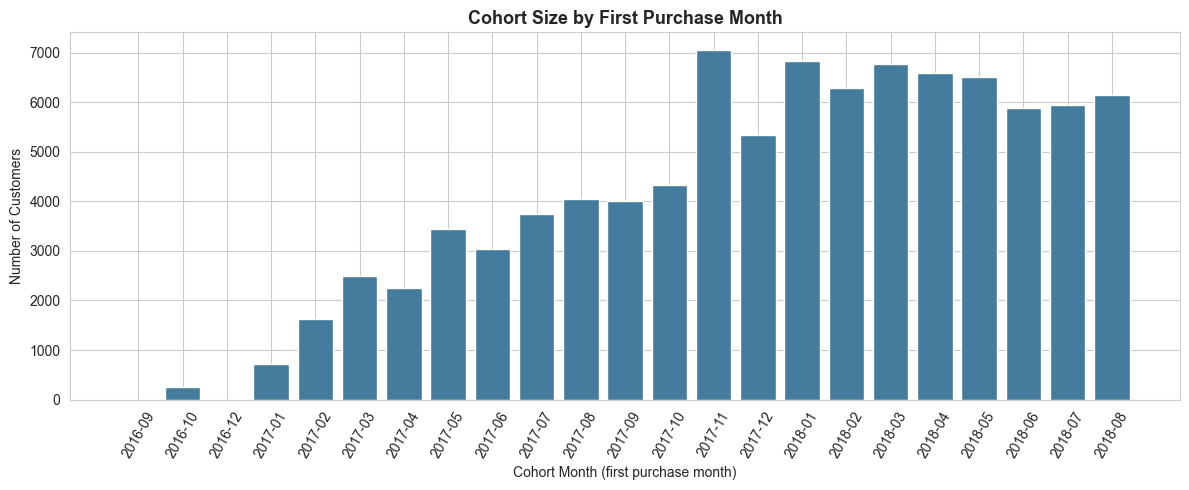

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(cohort_sizes.index, cohort_sizes.values, color='#457B9D')
ax.set_xlabel('Cohort Month (first purchase month)')
ax.set_ylabel('Number of Customers')
ax.set_title('Cohort Size by First Purchase Month')
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig('cohort_size_bar.png', dpi=120)
plt.show()

In [10]:
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100
retention.round(1)


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN
2017-05,100.0,0.5,0.5,0.3,0.3,0.3,0.4,0.1,0.3,0.3,0.3,0.3,0.2,0.0,0.2,0.2,NaN,NaN,NaN,NaN
2017-06,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.2,0.2,NaN,NaN,NaN,NaN,NaN


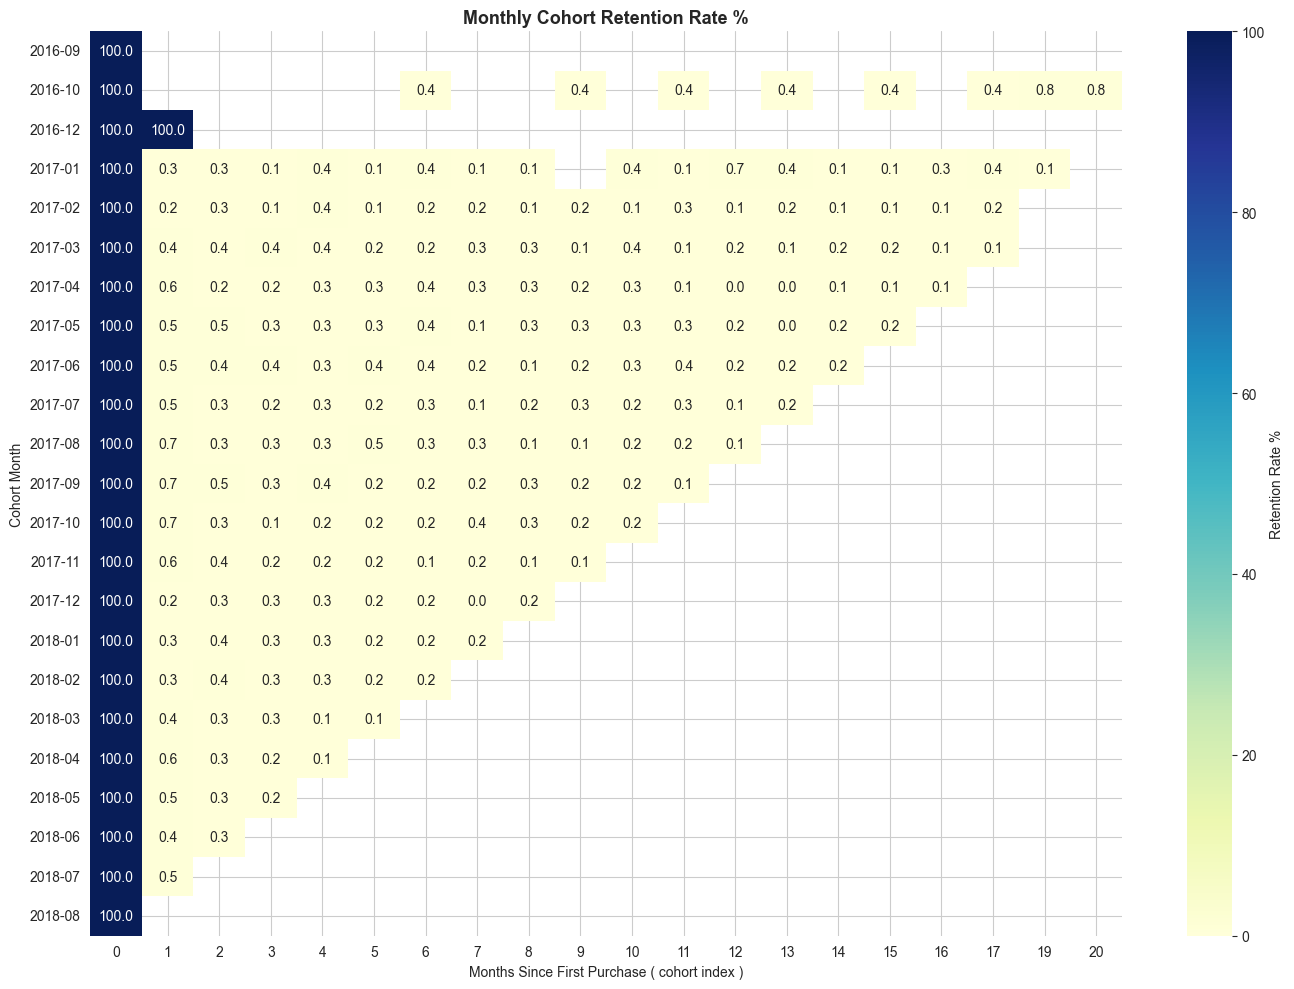

Average Month-1 retention rate (index 0 -> 1): 5.45%


In [11]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Retention Rate %'}, vmin=0, vmax=retention.iloc[:, 1:].max().max())
ax.set_title('Monthly Cohort Retention Rate %')
ax.set_xlabel('Months Since First Purchase ( cohort index )')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=120)
plt.show()
month1_retention = retention[1].dropna()
print(f"Average Month-1 retention rate (index 0 -> 1): {month1_retention.mean():.2f}%")


In [12]:
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

print(orders_delivered['delivery_days'].describe())
print(f"\nAverage delivery time: {orders_delivered['delivery_days'].mean():.1f} days")
print(f"Median delivery time: {orders_delivered['delivery_days'].median():.1f} days")
print(f"\nMissing delivery dates among delivered orders: {orders_delivered['delivery_days'].isna().sum()}")


count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

Average delivery time: 12.6 days
Median delivery time: 10.2 days

Missing delivery dates among delivered orders: 8


In [13]:
valid = orders_delivered.dropna(subset=['delivery_days', 'review_score']).copy()
bins = [0, 3, 7, 14, 21, np.inf]
labels = ['0-3 days', '4-7 days', '8-14 days', '15-21 days', '22+ days']
valid['delivery_bucket'] = pd.cut(valid['delivery_days'], bins=bins, labels=labels)
review_by_delivery = valid.groupby('delivery_bucket', observed=True)['review_score'].agg(['mean', 'count'])
review_by_delivery.columns = ['avg_review_score', 'order_count']
print(review_by_delivery.round(2))
print(f"\nOverall average review score: {valid['review_score'].mean():.2f}")
print(f"Correlation (delivery_days vs review_score): {valid['delivery_days'].corr(valid['review_score']):.3f}")


                 avg_review_score  order_count
delivery_bucket                               
0-3 days                     4.48         4733
4-7 days                     4.40        21200
8-14 days                    4.31        39997
15-21 days                   4.14        17582
22+ days                     3.12        12312

Overall average review score: 4.16
Correlation (delivery_days vs review_score): -0.334


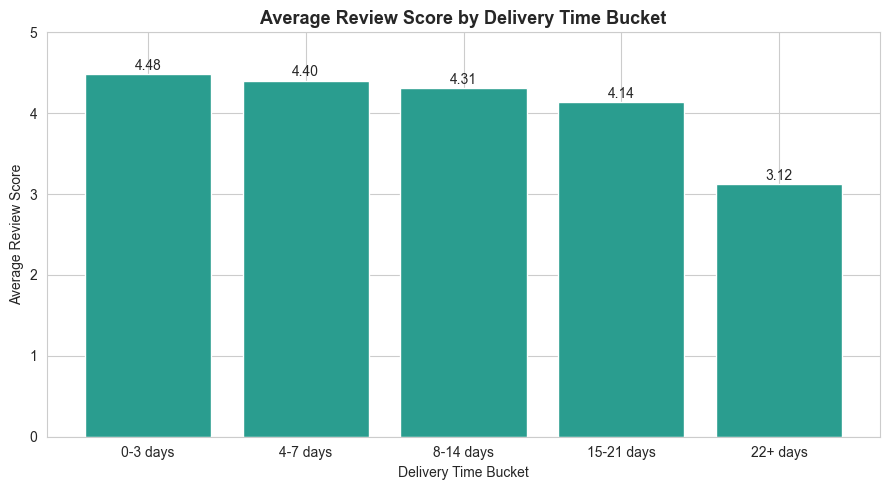

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(review_by_delivery.index.astype(str), review_by_delivery['avg_review_score'], color='#2A9D8F')
ax.set_xlabel('Delivery Time Bucket')
ax.set_ylabel('Average Review Score')
ax.set_title('Average Review Score by Delivery Time Bucket')
ax.set_ylim(0, 5)
for i, v in enumerate(review_by_delivery['avg_review_score']):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig('review_score_by_delivery_bucket.png', dpi=120)
plt.show()


In [15]:
items_with_cat = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_with_cat = items_with_cat.merge(category_translation, on='product_category_name', how='left')

order_category = items_with_cat.drop_duplicates(subset='order_id')[['order_id', 'product_category_name_english']]

cohort_cat = orders_delivered.merge(order_category, on='order_id', how='left')

electronics_cats = ['electronics', 'computers_accessories', 'telephony', 'computers', 'tablets_printing_image']
fashion_cats = [c for c in cohort_cat['product_category_name_english'].dropna().unique() if isinstance(c, str) and c.startswith('fashion')]

print("Electronics-ish categories found:", [c for c in electronics_cats if c in cohort_cat['product_category_name_english'].unique()])
print("Fashion categories found:", fashion_cats)

def retention_for_categories(data, categories, group_label):
    subset = data[data['product_category_name_english'].isin(categories)]
    sizes = subset.groupby('CohortMonth')['customer_unique_id'].nunique()
    piv = subset.groupby(['CohortMonth', 'CohortIndex'])['customer_unique_id'].nunique().reset_index()
    piv = piv.pivot(index='CohortMonth', columns='CohortIndex', values='customer_unique_id')
    ret = piv.divide(piv[0], axis=0) * 100
    overall_m1 = ret[1].mean() if 1 in ret.columns else np.nan
    print(f"{group_label}: {subset['customer_unique_id'].nunique()} unique customers, Month-1 retention avg = {overall_m1:.2f}%")
    return ret

electronics_retention = retention_for_categories(cohort_cat, electronics_cats, 'Electronics')
fashion_retention = retention_for_categories(cohort_cat, fashion_cats, 'Fashion')



Electronics-ish categories found: ['electronics', 'computers_accessories', 'telephony', 'computers', 'tablets_printing_image']
Fashion categories found: ['fashion_underwear_beach', 'fashion_bags_accessories', 'fashion_shoes', 'fashion_male_clothing', 'fashion_sport', 'fashion_childrens_clothes']
Electronics: 13132 unique customers, Month-1 retention avg = 0.48%
Fashion: 2232 unique customers, Month-1 retention avg = 7.06%


Top 3 largest cohorts: ['2017-11', '2018-01', '2018-03']


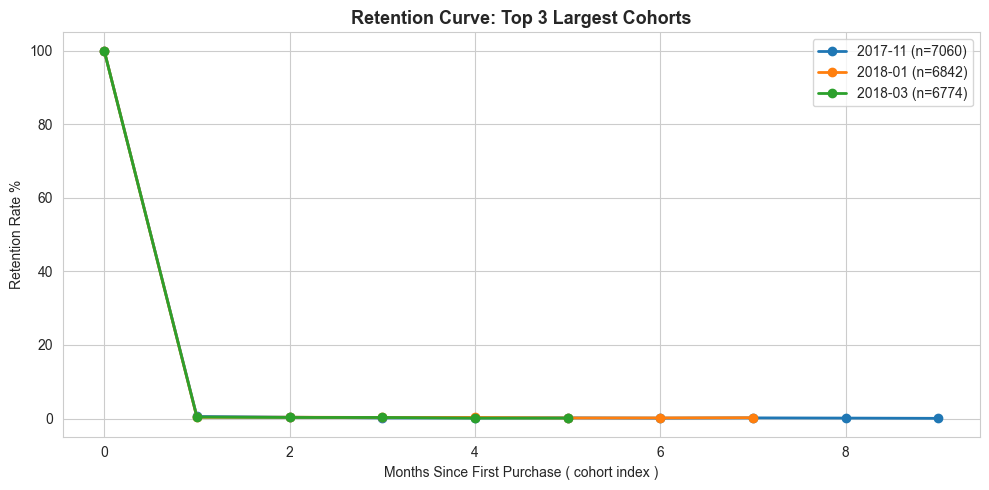

In [17]:
top3_cohorts = cohort_sizes.sort_values(ascending=False).head(3).index.tolist()
print(f"Top 3 largest cohorts: {top3_cohorts}")
fig, ax = plt.subplots(figsize=(10, 5))
for cohort in top3_cohorts:
    row = retention.loc[cohort].dropna()
    ax.plot(row.index, row.values, marker='o', linewidth=2, label=f'{cohort} (n={int(cohort_sizes[cohort])})')

ax.set_xlabel('Months Since First Purchase ( cohort index )')
ax.set_ylabel('Retention Rate %')
ax.set_title('Retention Curve: Top 3 Largest Cohorts')
ax.legend()
plt.tight_layout()
plt.savefig('top3_cohort_retention_curve.png', dpi=120)
plt.show()